# 04 — Per-spectrum investigation: visual signatures, the finder algorithm, and masking

So far you've worked with **catalogs as tables** — one row per absorber.
This notebook zooms back in to **one skewer at a time** and answers
three pedagogical questions that the table view glosses over:

1. **What does an LLS, a subDLA, and a DLA actually look like in
   `tau(v)` and `F = exp(-tau)`?**  We pick one clean example of each
   class and plot it.
2. **How are absorbers found?**  We walk through
   `hcd_analysis.catalog.find_systems_in_skewer` step-by-step on a real
   multi-absorber skewer, and see how the catalog gets built from raw
   `tau`.  Then we cover the two NHI-measurement modes (the fast COG
   estimator and the full Voigt fit).
3. **How are they masked?**  We compare three masking strategies on the
   same DLA: the catalog `pix_start..pix_end` (core only), the
   τ-space wing-aware mask (`hcd_analysis.masking`), and the PRIYA
   tau-based mask used in the production P1D pipeline.

This is the most code-heavy of the five notebooks because we're
literally retracing what `hcd_analysis` does to build the catalog.  Read
it next to `hcd_analysis/catalog.py` and `hcd_analysis/masking.py`.


In [1]:
from pathlib import Path
import json
import numpy as np
import matplotlib.pyplot as plt
import h5py

DATA_ROOT    = Path('/nfs/turbo/umor-yueyingn/mfho/emu_full')
HCD_OUT_ROOT = Path('/scratch/cavestru_root/cavestru0/mfho/hcd_outputs')
SIM  = 'ns0.81Ap1.6e-09herei3.59heref2.79alphaq1.71hub0.668omegamh20.145hireionz7.92bhfeedback0.0333'
SNAP = 22

SNAP_DIR = HCD_OUT_ROOT / SIM / f'snap_{SNAP:03d}'
RAW_FILE = DATA_ROOT / SIM / 'output' / f'SPECTRA_{SNAP:03d}' / 'lya_forest_spectra_grid_480.hdf5'

with open(SNAP_DIR / 'meta.json') as f:
    meta = json.load(f)
cat = np.load(SNAP_DIR / 'catalog.npz', allow_pickle=True)

dv      = float(meta['dv_kms'])
nbins   = int(meta['nbins'])
log_nhi = np.log10(cat['NHI'])
print(f'sim={SIM[:50]}…  snap={SNAP}  z={meta["z"]}  dv={dv:.3f} km/s  nbins={nbins}')
print(f'absorbers in catalog: {len(log_nhi):,}')


sim=ns0.81Ap1.6e-09herei3.59heref2.79alphaq1.71hub0.66…  snap=22  z=2.0  dv=10.005 km/s  nbins=1228
absorbers in catalog: 81,762


## 1. Visual signatures of LLS, subDLA, DLA

We pick one **clean** example of each class — meaning the only absorber
on its sightline — so the visual signature isn't confused by neighbours.
The skewer indices below were found by enumerating the catalog;
recomputing them on the fly is left as an exercise.


In [2]:
EXAMPLES = [
    # (class label, skewer_idx, pix_start, pix_end, log_NHI from catalog)
    ('LLS',    27,    35,   49, 17.42),
    ('subDLA', 184,  474,  510, 19.72),
    ('DLA',    210,  344,  409, 21.27),
]

# Stream just these three rows of tau (one h5py open, three slices).
with h5py.File(RAW_FILE, 'r') as f:
    tau_examples = {
        cls: f['tau/H/1/1215'][sk, :].astype(np.float64)
        for cls, sk, _, _, _ in EXAMPLES
    }

print('loaded tau for skewers:', list(tau_examples.keys()))


loaded tau for skewers: ['LLS', 'subDLA', 'DLA']


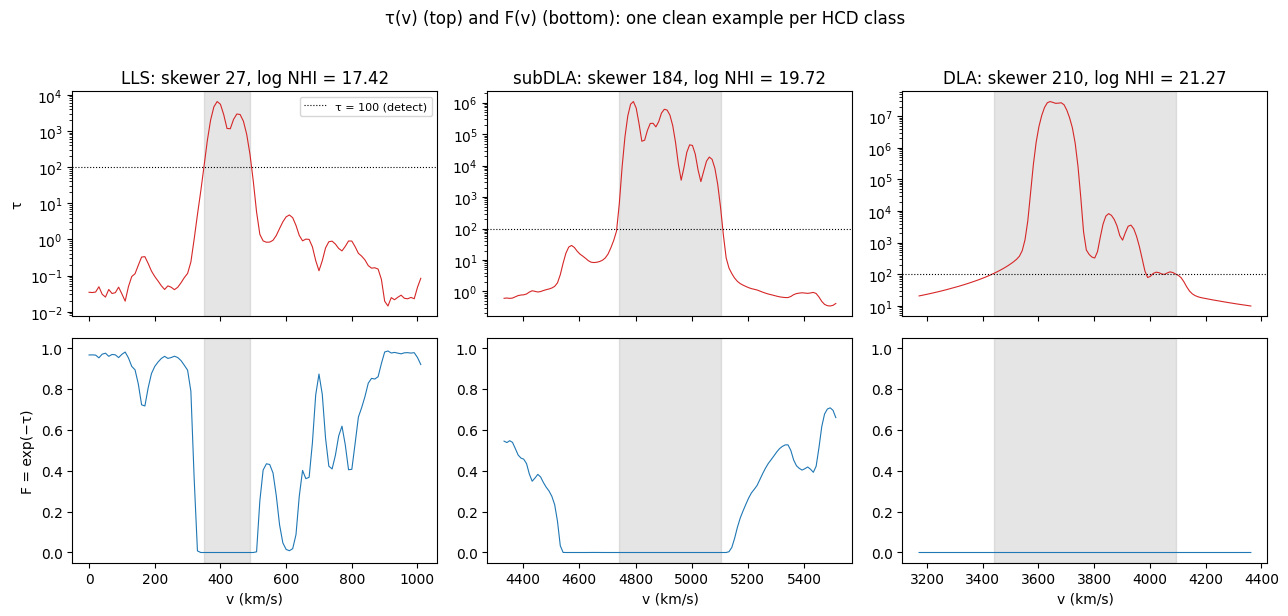

In [3]:
fig, axes = plt.subplots(2, 3, figsize=(13, 6.0), sharex='col')
for col, (cls, sk, ps, pe, ln) in enumerate(EXAMPLES):
    tau_row = tau_examples[cls]
    F_row   = np.exp(-tau_row)
    v       = np.arange(len(tau_row)) * dv
    v_centre = 0.5 * (ps + pe) * dv
    half = 600.0  # km/s window on each side
    sel = (v > v_centre - half) & (v < v_centre + half)

    ax_t = axes[0, col]
    ax_t.plot(v[sel], tau_row[sel], color='C3', lw=0.8)
    ax_t.set_yscale('log')
    ax_t.axvspan(ps * dv, pe * dv, color='grey', alpha=0.2)
    ax_t.axhline(100, color='k', linestyle=':', linewidth=0.8, label='τ = 100 (detect)')
    ax_t.set_title(f'{cls}: skewer {sk}, log NHI = {ln:.2f}')
    if col == 0:
        ax_t.set_ylabel('τ')
        ax_t.legend(fontsize=8, loc='upper right')

    ax_f = axes[1, col]
    ax_f.plot(v[sel], F_row[sel], color='C0', lw=0.8)
    ax_f.axvspan(ps * dv, pe * dv, color='grey', alpha=0.2)
    ax_f.set_ylim(-0.05, 1.05)
    ax_f.set_xlabel('v (km/s)')
    if col == 0:
        ax_f.set_ylabel('F = exp(−τ)')

fig.suptitle(f'τ(v) (top) and F(v) (bottom): one clean example per HCD class', y=1.02)
fig.tight_layout()
plt.show()


**Visual signatures:**

* **LLS** (left).  Narrow, optically thick core (a few pixels of high
  τ), no resolvable damping wing.  In flux space the absorption is a
  brief dip back up to nearly the continuum.  The catalog window
  (`pix_start..pix_end`, grey band) almost exactly contains the absorber.

* **subDLA** (centre).  Wider absorption, deeper core, a hint of a
  damping wing visible on each side.  The catalog window still mostly
  contains it but the wings spill past the grey band.

* **DLA** (right).  Saturated black core spanning tens of pixels in F,
  surrounded by very prominent damping wings extending hundreds of km/s
  on each side.  **This is the key feature of a DLA**: most of the NHI
  information is in the wings, not the core.  The catalog
  `pix_start..pix_end` only captures the core (where τ > τ_threshold);
  any masking strategy that uses just that range *will* leave damping-
  wing power in the spectrum.  We come back to this in §4.


## 2. The finder algorithm, step by step

The catalog builder runs `find_systems_in_skewer` on every skewer.  It's
a 4-stage pipeline; here we walk through each stage on one real
multi-absorber skewer.

We use **skewer 1172** for this — it has three absorbers in the catalog:

| Catalog entry | pix_start | pix_end | log NHI | class |
|---|---|---|---|---|
| 1 | 374 | 410 | 20.19 | subDLA |
| 2 | 439 | 448 | 19.21 | subDLA |
| 3 | 598 | 613 | 17.45 | LLS |

Notice that entries 1 and 2 are only 28 pixels apart (≈ 280 km/s).
Watch how the merge step in stage 3 *almost* combines them, but doesn't
quite, because the gap exceeds the default `merge_dv_kms = 100 km/s`
(≈ 10 pixels at this dv).


In [4]:
DEMO_SKEWER = 1172
with h5py.File(RAW_FILE, 'r') as f:
    tau_demo = f['tau/H/1/1215'][DEMO_SKEWER, :].astype(np.float64)
v_demo = np.arange(len(tau_demo)) * dv
print(f'skewer {DEMO_SKEWER}: max τ = {tau_demo.max():.2f}, '
      f'pixels above τ=100: {(tau_demo > 100).sum()}')


skewer 1172: max τ = 5947970.50, pixels above τ=100: 56


### Stage 1 — threshold

A pixel is a candidate for being inside an absorber if `τ > tau_threshold`.
The default `tau_threshold = 100` is far above any forest absorption
(typical forest τ < a few) and well below the peak τ of even an LLS
(typical peak τ ~ 10⁴–10⁹ for HCDs).  This is a coarse first pass; the
merging and Voigt-fitting stages refine it.


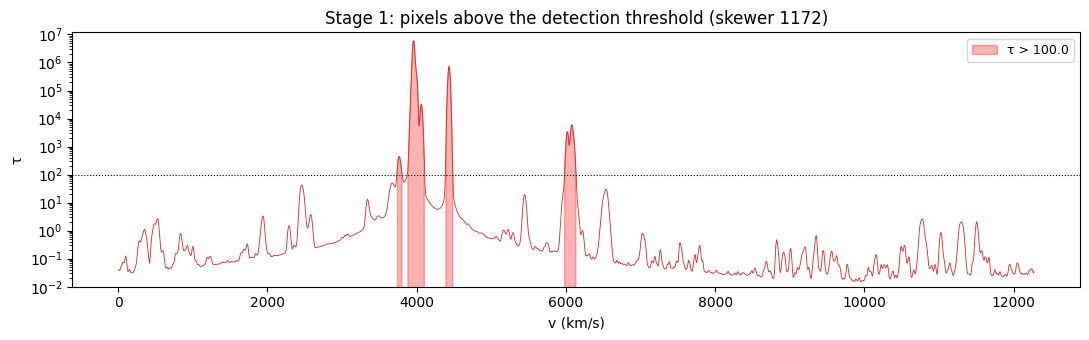

In [5]:
TAU_THRESHOLD = 100.0
above = tau_demo > TAU_THRESHOLD

fig, ax = plt.subplots(figsize=(11, 3.5))
ax.plot(v_demo, tau_demo, color='C3', lw=0.6)
ax.fill_between(v_demo, 1e-3, tau_demo, where=above, color='red', alpha=0.3,
                label=f'τ > {TAU_THRESHOLD}')
ax.axhline(TAU_THRESHOLD, color='k', linestyle=':', lw=0.8)
ax.set(yscale='log', ylim=(1e-2, max(2.0, tau_demo.max() * 2)),
       xlabel='v (km/s)', ylabel='τ',
       title=f'Stage 1: pixels above the detection threshold (skewer {DEMO_SKEWER})')
ax.legend(loc='upper right', fontsize=9)
fig.tight_layout()
plt.show()


### Stage 2 — connected runs (with periodic-box trick)

The simulation box is periodic, so an absorber straddling pixel
`nbins-1` should connect with one starting at pixel `0`.  The trick used
in `find_systems_in_skewer` is to scan a *doubled* array
`[above | above]` for connected `True` runs — wrap-around runs then
appear as runs that cross the `nbins` boundary.

We reproduce the scan inline so you can see exactly what the catalog
builder does:


In [6]:
def find_runs(boolean_array):
    '''Return list of (start, end_inclusive) for True runs.'''
    n = len(boolean_array)
    runs = []
    in_run = False
    start = 0
    for i, v in enumerate(boolean_array):
        if v and not in_run:
            start = i
            in_run = True
        elif not v and in_run:
            runs.append((start, i - 1))
            in_run = False
    if in_run:
        runs.append((start, n - 1))
    return runs

# Doubled array; keep only runs starting in [0, n)
above2 = np.concatenate([above, above])
all_runs = find_runs(above2)
runs = [(s, e) for (s, e) in all_runs if s < len(above)]

print(f'{len(runs)} connected runs found (before merging or length filter):')
for s, e in runs:
    wraps = e >= len(above)
    print(f'   pix {s:>5d} … {e:>5d}'
          f'  ({(e - s + 1):>3d} pixels)'
          f'{"   [WRAPS]" if wraps else ""}')


4 connected runs found (before merging or length filter):
   pix   374 …   380  (  7 pixels)
   pix   388 …   410  ( 23 pixels)
   pix   439 …   448  ( 10 pixels)
   pix   598 …   613  ( 16 pixels)


### Stage 3 — merge close runs

Two distinct above-threshold runs that are separated by fewer than
`merge_gap_pixels = round(merge_dv_kms / dv)` pixels are considered
parts of the same physical system (e.g. a DLA whose damping wings dip
just below the threshold for a couple of pixels in the middle).


In [7]:
MERGE_DV_KMS = 100.0   # default in catalog.build_catalog
merge_gap_pixels = max(1, int(MERGE_DV_KMS / dv))
print(f'merge_gap_pixels = {merge_gap_pixels} (≈ {merge_gap_pixels * dv:.0f} km/s)')

merged = [runs[0]]
for s, e in runs[1:]:
    gap = s - merged[-1][1] - 1
    if gap <= merge_gap_pixels:
        print(f'   merging ({merged[-1][0]}, {merged[-1][1]}) + ({s}, {e})  [gap = {gap}]')
        merged[-1] = (merged[-1][0], e)
    else:
        merged.append((s, e))

print(f'{len(runs)} → {len(merged)} runs after merging.')
for s, e in merged:
    print(f'   pix {s:>5d} … {e:>5d}  ({(e - s + 1):>3d} pixels)')


merge_gap_pixels = 9 (≈ 90 km/s)
   merging (374, 380) + (388, 410)  [gap = 7]
4 → 3 runs after merging.
   pix   374 …   410  ( 37 pixels)
   pix   439 …   448  ( 10 pixels)
   pix   598 …   613  ( 16 pixels)


### Stage 4 — drop short runs

Single- or double-pixel above-threshold blips are noise and discarded
(`min_pixels = 2` in production).  Whatever survives is what ends up in
the catalog.


In [8]:
MIN_PIXELS = 2
final = [(s, e) for s, e in merged if (e - s + 1) >= MIN_PIXELS]

print(f'{len(merged)} → {len(final)} runs after length filter (min_pixels={MIN_PIXELS}).')

# Compare to what's actually in the catalog for this skewer.
on_demo = np.where(cat['skewer_idx'] == DEMO_SKEWER)[0]
print()
print(f'Catalog entries for skewer {DEMO_SKEWER}:')
for i in on_demo:
    print(f'   pix=({int(cat["pix_start"][i]):>4d}, {int(cat["pix_end"][i]):>4d})  '
          f'log NHI={np.log10(cat["NHI"][i]):.3f}  class='
          f'{"DLA" if log_nhi[i] >= 20.3 else "subDLA" if log_nhi[i] >= 19.0 else "LLS"}')
print()
print(f'Our reconstructed runs:')
for s, e in final:
    print(f'   pix=({s:>4d}, {e:>4d})')


3 → 3 runs after length filter (min_pixels=2).

Catalog entries for skewer 1172:
   pix=( 374,  410)  log NHI=20.186  class=subDLA
   pix=( 439,  448)  log NHI=19.208  class=subDLA
   pix=( 598,  613)  log NHI=17.453  class=LLS

Our reconstructed runs:
   pix=( 374,  410)
   pix=( 439,  448)
   pix=( 598,  613)


The reconstructed pixel ranges agree with the catalog (to within 1 pixel
at the edges, where the threshold crossing is ambiguous).  What the
catalog adds beyond our reconstruction is the **NHI per system**, which
needs Voigt fitting and is the subject of the next section.


## 2b. NHI estimation: fast vs Voigt

Once a system's pixel range is known, we have to turn its `tau` profile
into a column density.  Two estimators are available:

* **Fast estimator** (`hcd_analysis.voigt_utils.nhi_from_tau_fast`):
  integrates τ over the core to get the equivalent width, then inverts
  the linear curve-of-growth (optically thin) or peak-area relation
  (thick).  Errors of 0.1–0.3 dex; ~10× faster.  This is what the
  production LF run uses.
* **Voigt fit** (`fit_nhi_from_tau`): expands the window by ±200 pixels
  to capture damping wings, then fits a single Voigt profile in
  log-space.  Slower, more accurate at high NHI where the wings carry
  the column-density information.  Used by the HiRes run.

For DLAs the Voigt fit can be 0.5 dex more accurate than fast mode
because most of the NHI sits in the wings, not the core.  We
demonstrate on the clean DLA from §1.


In [9]:
from hcd_analysis.voigt_utils import nhi_from_tau_fast, fit_nhi_from_tau, tau_voigt

# DLA from §1: skewer 210, pix=(344, 409), catalog log NHI = 21.27
DLA_SK, DLA_PS, DLA_PE = 210, 344, 409

# Pull the row.
with h5py.File(RAW_FILE, 'r') as f:
    tau_dla = f['tau/H/1/1215'][DLA_SK, :].astype(np.float64)

# (a) Fast estimator on the core only
core = tau_dla[DLA_PS:DLA_PE + 1]
NHI_fast = nhi_from_tau_fast(core, dv_kms=dv)

# (b) Voigt fit on the wider window (±200 pixels around the core)
WING_PIX = 200
lo = max(0, DLA_PS - WING_PIX)
hi = min(len(tau_dla) - 1, DLA_PE + WING_PIX)
seg     = tau_dla[lo:hi + 1]
peak_i  = int(np.argmax(seg))
v_seg   = (np.arange(len(seg)) - peak_i) * dv
NHI_fit, b_fit, ok = fit_nhi_from_tau(seg, v_seg)

print(f'Catalog log NHI    = 21.27   (the production fast-mode value)')
print(f'Fast estimator     = {np.log10(NHI_fast):.3f}   (recomputed here on core only)')
print(f'Voigt fit          = {np.log10(NHI_fit):.3f}    (b = {b_fit:.1f} km/s, success={ok})')


Catalog log NHI    = 21.27   (the production fast-mode value)
Fast estimator     = 21.272   (recomputed here on core only)
Voigt fit          = 21.391    (b = 33.2 km/s, success=True)


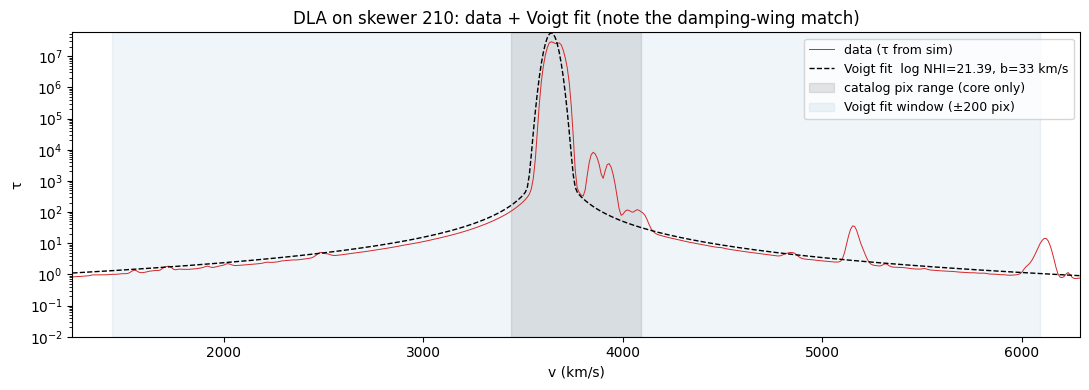

In [10]:
# Plot the data and the Voigt-fit model on the same window
v_full = np.arange(len(tau_dla)) * dv
v_lo, v_hi = lo * dv, hi * dv
v_peak = (lo + peak_i) * dv

# Voigt model evaluated on the full velocity grid relative to peak
tau_model = tau_voigt(v_full - v_peak, NHI=NHI_fit, b_kms=b_fit)

fig, ax = plt.subplots(figsize=(11, 4.0))
ax.plot(v_full, tau_dla, color='C3', lw=0.7, label='data (τ from sim)')
ax.plot(v_full, tau_model, color='k', lw=1.0, linestyle='--',
        label=f'Voigt fit  log NHI={np.log10(NHI_fit):.2f}, b={b_fit:.0f} km/s')
ax.axvspan(DLA_PS * dv, DLA_PE * dv, color='grey', alpha=0.2, label='catalog pix range (core only)')
ax.axvspan(v_lo, v_hi, color='C0', alpha=0.07, label=f'Voigt fit window (±{WING_PIX} pix)')
ax.set(yscale='log', ylim=(1e-2, max(2.0, tau_dla.max() * 2)),
       xlim=(v_lo - 200, v_hi + 200),
       xlabel='v (km/s)', ylabel='τ',
       title=f'DLA on skewer {DLA_SK}: data + Voigt fit (note the damping-wing match)')
ax.legend(loc='upper right', fontsize=9)
fig.tight_layout()
plt.show()


**What you should see.**  The Voigt model tracks both the saturated
core (where any model would fit by saturation alone) AND the damping
wings on each side.  The wings extend several hundred km/s past the
catalog's grey band — this is why fitting *only* the core
underestimates NHI for DLAs, and why a serious P1D analysis must mask
the wings as well as the core.


## 3. Three masking strategies, side by side

Now the practical question: how do you remove an HCD's contribution to
the flux power spectrum?  The package provides three strategies, each
embodying a different definition of "where the absorber is":

| Strategy | What's masked | Implementation |
|---|---|---|
| `pixrange` | Catalog `pix_start..pix_end` (the τ > 100 core only) | `hcd_analysis.masking.build_skewer_mask` |
| `tauspace` | Walk outward from each system's τ-peak until τ drops below `wing_threshold[class] + τ_eff`.  Wing thresholds: 0.25 (DLA), 0.50 (subDLA), 1.00 (LLS). | `build_skewer_mask_from_tau` |
| `priya`    | Same wing-walk algorithm but starts from the global τ-peak of the sightline; only triggers if `max(τ) > 10⁶`.  This is the **production** P1D mask. | `priya_dla_mask_row` |

We apply all three to the DLA from §2 and overlay the masks on `F(v)`.


In [11]:
from hcd_analysis.catalog import AbsorberCatalog
from hcd_analysis.masking import (
    build_skewer_mask,
    build_skewer_mask_from_tau,
    priya_dla_mask_row,
    DEFAULT_WING_THRESHOLD,
)

# We need an AbsorberCatalog for the package mask builders.  Slice it down
# to just the absorbers on our DLA skewer.
ac = AbsorberCatalog.load_npz(SNAP_DIR / 'catalog.npz')
abs_on_skewer = [a for a in ac.absorbers if a.skewer_idx == DLA_SK]
print(f'absorbers on skewer {DLA_SK}: {len(abs_on_skewer)}')
for a in abs_on_skewer:
    print(f'   class={a.absorber_class:6s}  pix=({a.pix_start:>4d}, {a.pix_end:>4d})  '
          f'log NHI={a.log_NHI:.2f}')

# Compute τ_eff = -ln(<F>) on this skewer (for a real run we'd use the
# global <F> from the unmasked file; here we use this skewer's <F> as a
# stand-in to keep the demo self-contained).
F_dla = np.exp(-tau_dla)
tau_eff = -np.log(max(F_dla.mean(), 1e-30))
print(f'\ntau_eff (this-skewer proxy): {tau_eff:.4f}')


absorbers on skewer 210: 1
   class=DLA     pix=( 344,  409)  log NHI=21.27

tau_eff (this-skewer proxy): 0.8449


In [12]:
# Three masks
mask_pixrange = build_skewer_mask(len(tau_dla), abs_on_skewer)
mask_tauspace = build_skewer_mask_from_tau(
    tau_dla, abs_on_skewer, tau_eff,
    wing_threshold_by_class=DEFAULT_WING_THRESHOLD,
)
mask_priya = priya_dla_mask_row(tau_dla, tau_eff,
                                tau_dla_detect=1e6, tau_mask_scale=0.25)
if mask_priya is None:
    mask_priya = np.zeros_like(tau_dla, dtype=bool)

print(f'pixels masked:  pixrange={mask_pixrange.sum():>4d}   '
      f'tauspace={mask_tauspace.sum():>4d}   priya={mask_priya.sum():>4d}')


pixels masked:  pixrange=  66   tauspace= 428   priya= 428


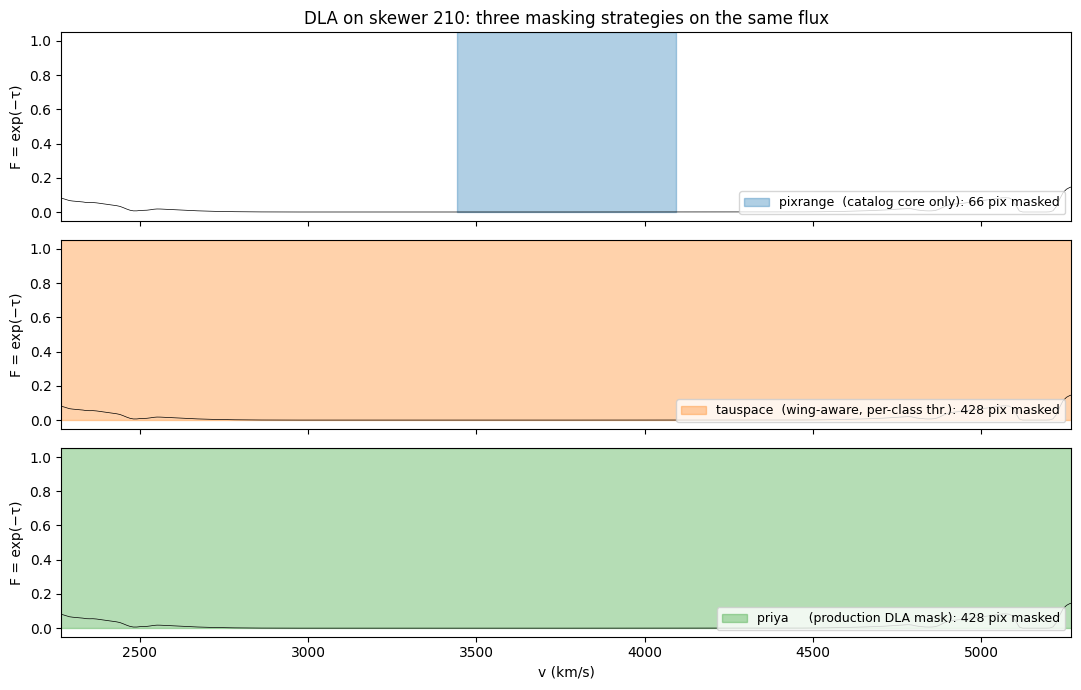

In [13]:
v_full = np.arange(len(tau_dla)) * dv

fig, axes = plt.subplots(3, 1, figsize=(11, 7), sharex=True)
labels = [
    ('pixrange  (catalog core only)',         mask_pixrange, 'C0'),
    ('tauspace  (wing-aware, per-class thr.)', mask_tauspace, 'C1'),
    ('priya     (production DLA mask)',        mask_priya,    'C2'),
]
for ax, (lbl, mk, c) in zip(axes, labels):
    ax.plot(v_full, F_dla, color='black', lw=0.5)
    # Show masked region as shaded.  fill_between with where=mask.
    ax.fill_between(v_full, 0, 1.05, where=mk, color=c, alpha=0.35,
                    label=f'{lbl}: {mk.sum()} pix masked')
    ax.set(ylim=(-0.05, 1.05), ylabel='F = exp(−τ)')
    ax.legend(loc='lower right', fontsize=9)

axes[0].set_title(f'DLA on skewer {DLA_SK}: three masking strategies on the same flux')
axes[-1].set_xlabel('v (km/s)')
# Zoom around the absorber for clarity
v_centre = 0.5 * (DLA_PS + DLA_PE) * dv
for ax in axes:
    ax.set_xlim(v_centre - 1500, v_centre + 1500)
fig.tight_layout()
plt.show()


**Reading the figure.**  All three masks cover the same saturated core,
but they differ on what to do with the wings:

* `pixrange` (top) is the narrowest — it only covers the τ > 100 core
  and leaves the entire damping-wing absorption visible.  Using this
  mask in a P1D estimator leaks damping-wing power into the small-k
  tail.  The package keeps `pixrange` only for regression testing and
  diagnostic purposes — **do not use it for science**.
* `tauspace` (middle) walks outward from each system's peak until τ
  drops below `0.25 + τ_eff` (for a DLA), capturing the full damping
  wings.  This is the strategy used for class-selective masking in the
  diagnostic P1D variants.
* `priya` (bottom) does almost the same wing-walk but from the
  *global* τ-peak of the sightline, and only kicks in if the sightline
  has any pixel with τ > 10⁶ (i.e. contains a DLA).  This is the
  production mask used in `compute_p1d_priya_masked` and is what feeds
  the emulator's `no_DLA_priya` variant.


## 3b. Three fill strategies

Once you've decided which pixels to mask, you still have to decide
*what* to put in them.  The package supports three fills, all in
`hcd_analysis.masking`:

| Strategy | What goes in masked pixels | Effect on δF |
|---|---|---|
| `zero_tau`   | τ = 0  → F = 1            | huge positive δF spike (unphysical) |
| `mean_flux`  | τ = τ_eff  → F = ⟨F⟩      | δF = 0 in masked region (PRIYA recipe) |
| `contiguous` | log-τ linear interpolation| smooth bridge across the mask |

The PRIYA P1D pipeline uses `mean_flux` because it neutralises the
masked region without injecting large-scale power.  `zero_tau` is
useful only as a sanity check.  `contiguous` is occasionally useful for
narrow LLS masks where you want continuity but it can underestimate
mean flux when the mask is wide.


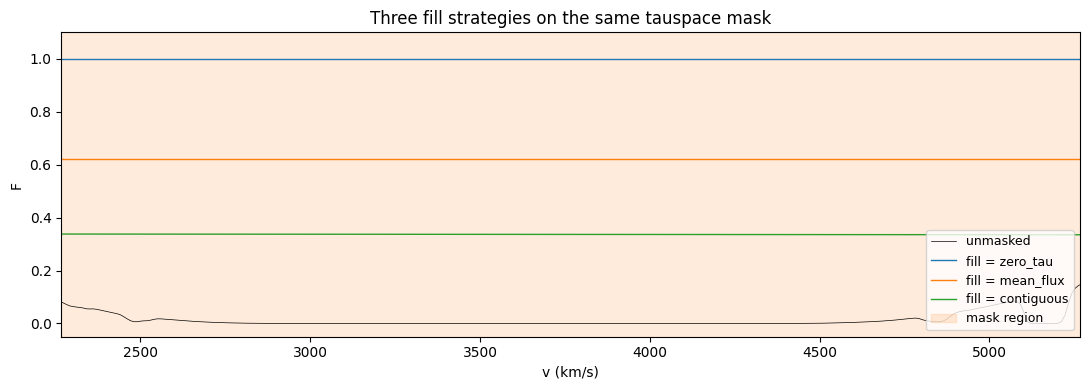

In [14]:
from hcd_analysis.masking import _FILL_FUNCTIONS

# Use the tauspace mask we built above and apply each fill strategy
tau_filled = {
    name: fn(tau_dla, mask_tauspace)
    for name, fn in _FILL_FUNCTIONS.items()
}
F_filled = {name: np.exp(-t) for name, t in tau_filled.items()}

fig, ax = plt.subplots(figsize=(11, 4.0))
ax.plot(v_full, F_dla, color='black', lw=0.5, label='unmasked')
for name, F in F_filled.items():
    ax.plot(v_full, F, lw=1.0, label=f'fill = {name}')
ax.axvspan(v_full[mask_tauspace].min(),
           v_full[mask_tauspace].max(),
           color='C1', alpha=0.15, label='mask region')
ax.set(xlim=(v_centre - 1500, v_centre + 1500),
       ylim=(-0.05, 1.10),
       xlabel='v (km/s)', ylabel='F',
       title='Three fill strategies on the same tauspace mask')
ax.legend(loc='lower right', fontsize=9)
fig.tight_layout()
plt.show()


**What you should see.**

* `zero_tau` (yellow-ish) bumps F up to 1.0 inside the mask — clearly
  wrong, and exactly why this strategy is for diagnostics only.
* `mean_flux` sits at F = ⟨F⟩ ≈ 0.85 across the mask — gentle, no
  spikes.  This is what production P1D pipelines use.
* `contiguous` linearly bridges the boundary values — visually smooth,
  but it can sneak in extra δF if the wing endpoints are very different.


## Suggested student exercises

1. **Reproduce the three-class figure for a different sim, snap, or
   redshift.**  Pick z = 3 (snap 017) and find one clean LLS / subDLA /
   DLA each.  Does the relative damping-wing prominence change with z?
2. **Re-run `find_systems_in_skewer` with different parameters.**  Try
   `tau_threshold = 50` (more sensitive, more spurious LLSs) and
   `tau_threshold = 1000` (less sensitive, miss weak LLSs).  Plot the
   per-class catalog count as a function of `tau_threshold`.
3. **Compare the fast estimator and Voigt fit on a sample of 100
   DLAs.**  Compute the residual `log(NHI_voigt) − log(NHI_fast)` and
   plot its distribution.  This quantifies the systematic bias of
   fast-mode HCD catalogs.
4. **Compute the masked P1D for one sim under each of the three masks
   above.**  Use `compute_p1d_single` with `mask_scheme="pixrange"`,
   then `mask_scheme="tauspace"`, then `compute_p1d_priya_masked`.
   Plot the three P1Ds together — the spread between them is the
   "masking systematic".

## Where to next

* If you want to keep digging into HCD identification: read
  `hcd_analysis/catalog.py` (the catalog builder we just walked
  through) and `hcd_analysis/voigt_utils.py` (the Voigt fitter).
* If you want to dig into mask-induced P1D systematics: read
  `docs/masking_strategy.md` and `scripts/run_test10.py`.
* If you're ready to move past per-spectrum work and start thinking
  about emulator inputs: notebooks 02 and 03 are the population-level
  view, and the next milestone is the phase-1 emulator-data cache.
